<a href="https://colab.research.google.com/github/Sushantbhandari7/Numpy/blob/main/end_to_end_machinelearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')




MessageError: Error: credential propagation was unsuccessful

In [2]:
import pandas as pd

import numpy as np



In [3]:
df = pd.read_csv('/content/placement.csv')
print(df)

    Unnamed: 0  cgpa     iq  placement
0            0   6.8  123.0          1
1            1   5.9  106.0          0
2            2   5.3  121.0          0
3            3   7.4  132.0          1
4            4   5.8  142.0          0
..         ...   ...    ...        ...
95          95   4.3  200.0          0
96          96   4.4   42.0          0
97          97   6.7  182.0          1
98          98   6.3  103.0          1
99          99   6.2  113.0          1

[100 rows x 4 columns]


In [4]:
df = pd.head()

AttributeError: module 'pandas' has no attribute 'head'

In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df = df.iloc[:,1:]

In [8]:
print(df.head())

   cgpa     iq  placement
0   6.8  123.0          1
1   5.9  106.0          0
2   5.3  121.0          0
3   7.4  132.0          1
4   5.8  142.0          0


In [9]:
import matplotlib.pyplot as plt


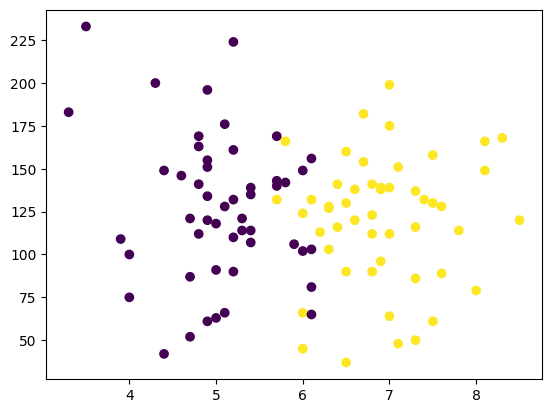

In [12]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

<BarContainer object of 100 artists>

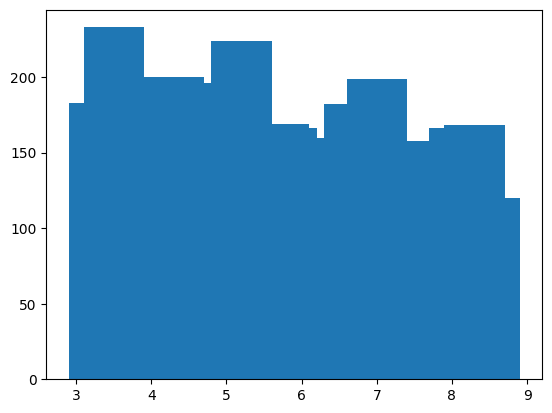

In [11]:
plt.bar(df['cgpa'],df['iq'])

In [19]:
X = df.iloc[ :,0:2]
Y = df.iloc[ :,-1]


In [20]:

X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [16]:
Y

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
94,4.7,52.0,0
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1


In [24]:
from sklearn.model_selection import train_test_split

# Redefine X and Y to ensure they have consistent numbers of samples.
# X should contain the feature columns (cgpa, iq).
# Y should contain the target column (placement).
X = df.iloc[:, 0:2]
Y = df.iloc[:, -1]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1)

In [25]:
X_train

,cgpa,iq
29,7.0,112.0
98,6.3,103.0
41,5.4,114.0
96,4.4,42.0
47,5.2,161.0
...,...,...
77,7.3,50.0
70,6.3,127.0
34,4.8,163.0
76,4.9,155.0


In [26]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()


In [29]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
X_test

array([[-0.22887402,  0.23841551],
       [ 0.02754086,  0.65866406],
       [ 0.54037062,  0.38673853],
       [-0.65623216, -0.79984559],
       [ 0.88225713,  1.89468919],
       [ 0.7967855 ,  0.38673853],
       [-0.99811867,  0.46090004],
       [ 0.11301248, -1.02233012],
       [ 0.36942737,  0.46090004],
       [ 1.13867201,  0.36201803]])

In [31]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [32]:
clf.fit(X_train,Y_train)

LogisticRegression()

In [33]:
Y_pred = clf.predict(X_test)

array([0, 0, 1, 0, 1, 1, 0, 1, 1, 1])

In [34]:
Y_test

,placement
87,1
33,0
48,1
28,0
26,1
11,1
51,0
78,0
54,1
61,1


In [36]:
from sklearn.metrics import accuracy_score
Y_pred = clf.predict(X_test)
accuracy_score(Y_test,Y_pred)

0.8

<Axes: >

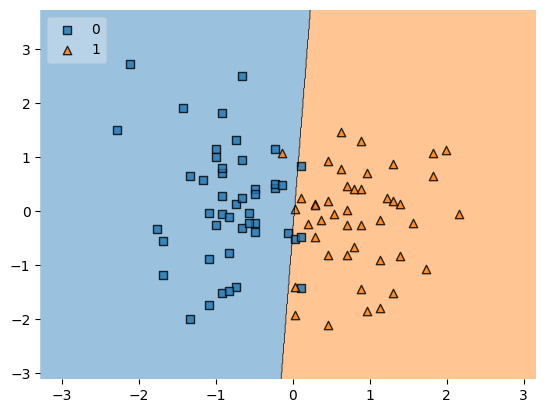

In [39]:
from mlxtend.plotting import plot_decision_regions
import numpy as np

plot_decision_regions(X_train, Y_train.to_numpy().astype(np.int64), clf=clf, legend=2)

In [40]:
import pickle

In [41]:
pickle.dump(clf,open('model.pkl','wb'))